# Joint EDA: Exploratory Data Analysis

This notebook **loads the joint county–year dataset** (built by **`build_joint_dataset.ipynb`**) and runs exploratory analysis: missingness, correlations, maps, and bivariate plots.

**Input:** `data/joint_county_year_2018_2019.csv`  
**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`. Optional: `geopandas` for choropleth maps.


In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import geopandas as gpd
    HAS_GEOPANDAS = True
except ImportError:
    HAS_GEOPANDAS = False


In [2]:
# Load joint dataset (produced by build_joint_dataset.ipynb)
joint = pd.read_csv("../data/joint_county_year_2018_2019.csv")
joint["FIPS"] = joint["FIPS"].astype(str).str.zfill(5)
joint["YEAR"] = joint["YEAR"].astype(int)
print("Joint shape:", joint.shape)
print("Years:", sorted(joint["YEAR"].unique().tolist()))
joint.head()


Joint shape: (6128, 487)
Years: [2018, 2019]


,FIPS,YEAR,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,pesticide_pyrethroid_kg,...,chemical_reliance_acre_rescaled,ipm_breadth_value,chemical_reliance_value,ipm_doc_coverage_share,mean_text_quality,mean_geo_confidence,weighted_doc_age,county_crop_concentration,specialty_crop_share,total_ag_value
0,01001,2018,34773.85,3690.60,397.30,6995.35,0.0,2033.75,20854.80,119.65,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.135210,0.0,0.0
1,01001,2019,21120.00,2582.55,9.70,5230.55,0.0,763.95,11639.25,16.80,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.135210,0.0,0.0
2,01003,2018,277331.10,61192.90,1327.20,10561.50,0.0,4287.00,185663.25,1982.75,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.218801,0.0,0.0
3,01003,2019,125643.65,30532.30,24.45,4197.00,0.0,7219.45,75275.55,127.30,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.218801,0.0,0.0
4,01005,2018,63256.35,3484.60,306.80,11760.30,0.0,1455.95,42686.50,626.70,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,0.211528,0.0,0.0


## 6. Joint EDA

**IPM/crop indices:**
- **Acreage-weighted** (`ipm_breadth_acre`, `chemical_reliance_acre`): Not null, but often small or zero. They are only non-zero when a county's crop mix matches (crop, state) pairs in the IPM API; limited API coverage or zero document scores produce mostly 0s.
- **Value-weighted** (`ipm_breadth_value`, `chemical_reliance_value`): **All NaN** because `crop_value` is not populated (NASS not integrated). To get value-weighted IPM, add crop value data in the county-crop-year step.
- **total_ag_value** and **specialty_crop_share**: `total_ag_value` is NaN without NASS; `specialty_crop_share` is from CDL (share of fruit/veg acres) and can be 0 in many counties.

In [3]:
joint.describe()

joint.head(10)

# --- IPM and crop indices (county-year collapsed): summary ---
IPM_MEASURE_COLS = ["ipm_breadth_acre", "chemical_reliance_acre", "ipm_breadth_acre_rescaled", "chemical_reliance_acre_rescaled",
                   "ipm_breadth_value", "chemical_reliance_value", "ipm_doc_coverage_share", "mean_text_quality", "mean_geo_confidence", "weighted_doc_age",
                   "county_crop_concentration", "specialty_crop_share", "total_ag_value"]
ipm_cols_present = [c for c in IPM_MEASURE_COLS if c in joint.columns]
if ipm_cols_present:
    print("IPM / crop indices (county-year collapsed):")
    print(joint[ipm_cols_present].describe().round(4))
    print("\nNon-null counts:", joint[ipm_cols_present].notna().sum().to_dict())
else:
    print("No IPM columns in joint (county_year_collapsed not merged).")

IPM / crop indices (county-year collapsed):
       ipm_breadth_acre  chemical_reliance_acre  ipm_breadth_acre_rescaled  \
count         6122.0000               6122.0000                  6122.0000   
mean             0.0298                  0.0226                     0.0432   
std              0.1133                  0.0882                     0.1649   
min              0.0000                  0.0000                     0.0000   
25%              0.0000                  0.0000                     0.0000   
50%              0.0000                  0.0000                     0.0000   
75%              0.0000                  0.0000                     0.0000   
max              0.4868                  0.4341                     0.7317   

       chemical_reliance_acre_rescaled  ipm_breadth_value  \
count                        6122.0000                0.0   
mean                            0.0373                NaN   
std                             0.1528                NaN   
min      

### 6a. Missingness: Geographic distribution and correlated patterns

We check (1) whether missingness is geographically clustered (e.g., certain states) and (2) whether missingness in one dataset tends to co-occur with missingness in others.

**Note:** Cropland is now fetched for all counties (parallel API requests). Any remaining missingness is from API failures for specific counties.

In [4]:
# Missingness indicators (1 = has data, 0 = missing)
print("Overall missingness:")
print("  Pesticide (total_kg):", joint["pesticide_total_kg"].isna().sum(), "counties missing (base dataset)")
print("  Census (population):", joint["population"].isna().sum(), "counties missing")
print("  Cropland:", joint["cropland_acres"].isna().sum(), "counties missing")
print("  PLACES (CASTHMA):", joint["CASTHMA"].isna().sum(), "counties missing")
if "county_crop_concentration" in joint.columns:
    print("  Crop/IPM (county_year_collapsed):", joint["county_crop_concentration"].isna().sum(), "county-years missing")
print()
joint["state_fips"] = joint["FIPS"].astype(str).str.zfill(5).str[:2]
has_crop_ipm = joint["county_crop_concentration"].notna().astype(int) if "county_crop_concentration" in joint.columns else pd.Series(0, index=joint.index)
miss = pd.DataFrame({
    "has_pesticide": joint["pesticide_total_kg"].notna().astype(int),
    "has_census": joint["population"].notna().astype(int),
    "has_cropland": joint["cropland_acres"].notna().astype(int),
    "has_places": joint["CASTHMA"].notna().astype(int),
    "has_crop_ipm": has_crop_ipm,
}, index=joint.index)
miss["state_fips"] = joint["state_fips"]
miss["n_missing"] = 5 - miss[["has_pesticide", "has_census", "has_cropland", "has_places", "has_crop_ipm"]].sum(axis=1)

# Geographic distribution: % missing by state
state_miss = miss.groupby("state_fips").agg(
    n_counties=("has_census", "count"),
    pct_missing_pesticide=("has_pesticide", lambda x: 100 * (1 - x.mean())),
    pct_missing_census=("has_census", lambda x: 100 * (1 - x.mean())),
    pct_missing_cropland=("has_cropland", lambda x: 100 * (1 - x.mean())),
    pct_missing_places=("has_places", lambda x: 100 * (1 - x.mean())),
    pct_missing_crop_ipm=("has_crop_ipm", lambda x: 100 * (1 - x.mean())),
).round(1)
state_miss = state_miss[state_miss["n_counties"] >= 5]  # at least 5 counties
state_miss.sort_values("pct_missing_cropland", ascending=False).head(15)

Overall missingness:
  Pesticide (total_kg): 0 counties missing (base dataset)
  Census (population): 0 counties missing
  Cropland: 6 counties missing
  PLACES (CASTHMA): 40 counties missing
  Crop/IPM (county_year_collapsed): 6 county-years missing



,n_counties,pct_missing_pesticide,pct_missing_census,pct_missing_cropland,pct_missing_places,pct_missing_crop_ipm
state_fips,,,,,,
18,184,0.0,0.0,2.2,0.0,2.2
17,204,0.0,0.0,1.0,0.0,1.0
01,134,0.0,0.0,0.0,0.0,0.0
44,10,0.0,0.0,0.0,0.0,0.0
34,40,0.0,0.0,0.0,100.0,0.0
35,66,0.0,0.0,0.0,0.0,0.0
36,122,0.0,0.0,0.0,0.0,0.0
37,200,0.0,0.0,0.0,0.0,0.0
38,106,0.0,0.0,0.0,0.0,0.0


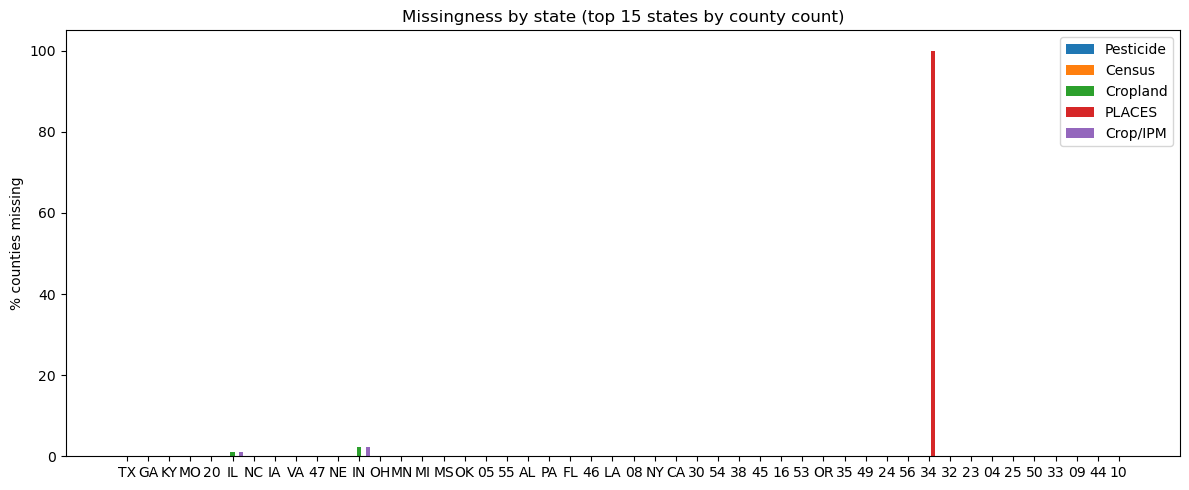

In [ ]:
# Bar chart: missingness by state (states with most counties)
# State FIPS codes: 01=AL, 06=CA, 12=FL, 13=GA, 17=IL, 18=IN, 19=IA, 21=KY, 22=LA, 26=MI, 27=MN, 28=MS, 29=MO, 31=NE, 36=NY, 37=NC, 39=OH, 40=OK, 41=OR, 42=PA, 48=TX, 51=VA
STATE_ABBR = {"01":"AL","06":"CA","12":"FL","13":"GA","17":"IL","18":"IN","19":"IA","21":"KY","22":"LA","26":"MI","27":"MN","28":"MS","29":"MO","31":"NE","36":"NY","37":"NC","39":"OH","40":"OK","41":"OR","42":"PA","48":"TX","51":"VA"}
fig, ax = plt.subplots(figsize=(15, 5))
plot_states = state_miss.nlargest(200, "n_counties").index
labels = [STATE_ABBR.get(s, s) for s in plot_states]
x = np.arange(len(plot_states))
w = 0.2
ax.bar(x - 2*w, state_miss.loc[plot_states, "pct_missing_pesticide"], width=w, label="Pesticide", color="C0")
ax.bar(x - w, state_miss.loc[plot_states, "pct_missing_census"], width=w, label="Census", color="C1")
ax.bar(x, state_miss.loc[plot_states, "pct_missing_cropland"], width=w, label="Cropland", color="C2")
ax.bar(x + w, state_miss.loc[plot_states, "pct_missing_places"], width=w, label="PLACES", color="C3")
if "pct_missing_crop_ipm" in state_miss.columns:
    ax.bar(x + 2*w, state_miss.loc[plot_states, "pct_missing_crop_ipm"], width=w, label="Crop/IPM", color="C4")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% counties missing")
ax.set_title("Missingness by state (top 15 states by county count)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Correlated missingness: do the same counties tend to be missing across datasets?
miss_missing = 1 - miss[["has_pesticide", "has_census", "has_cropland", "has_places", "has_crop_ipm"]]
miss_missing.columns = ["missing_pesticide", "missing_census", "missing_cropland", "missing_places", "missing_crop_ipm"]
print("Correlation of MISSING indicators (1=missing, 0=has data):")
print("  Positive = counties missing in one tend to be missing in the other (geographic/structural overlap)")
print(miss_missing.corr().round(3))
print("\nCrosstab: Census missing × Cropland missing")
print(pd.crosstab(miss["has_census"] == 0, miss["has_cropland"] == 0, margins=True))
print("\nCrosstab: Census missing × PLACES missing")
print(pd.crosstab(miss["has_census"] == 0, miss["has_places"] == 0, margins=True))
print("\nCrosstab: Cropland missing × PLACES missing")
print(pd.crosstab(miss["has_cropland"] == 0, miss["has_places"] == 0, margins=True))

Correlation of MISSING indicators (1=missing, 0=has data):
  Positive = counties missing in one tend to be missing in the other (geographic/structural overlap)
                   missing_pesticide  missing_census  missing_cropland  \
missing_pesticide                NaN             NaN               NaN   
missing_census                   NaN             NaN               NaN   
missing_cropland                 NaN             NaN             1.000   
missing_places                   NaN             NaN            -0.003   
missing_crop_ipm                 NaN             NaN             1.000   

                   missing_places  missing_crop_ipm  
missing_pesticide             NaN               NaN  
missing_census                NaN               NaN  
missing_cropland           -0.003             1.000  
missing_places              1.000            -0.003  
missing_crop_ipm           -0.003             1.000  

Crosstab: Census missing × Cropland missing
has_cropland  False  True 

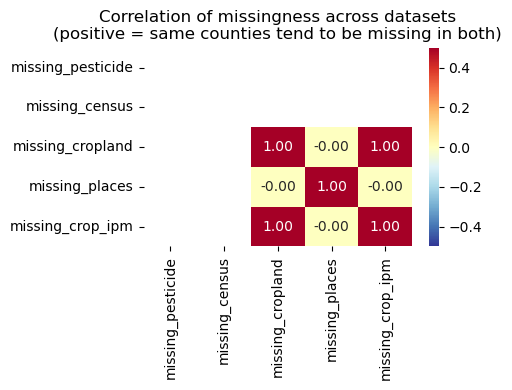

In [7]:
# Heatmap: correlation of missingness across datasets
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(miss_missing.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("Correlation of missingness across datasets\n(positive = same counties tend to be missing in both)")
plt.tight_layout()
plt.show()

### 6b. Correlation matrix

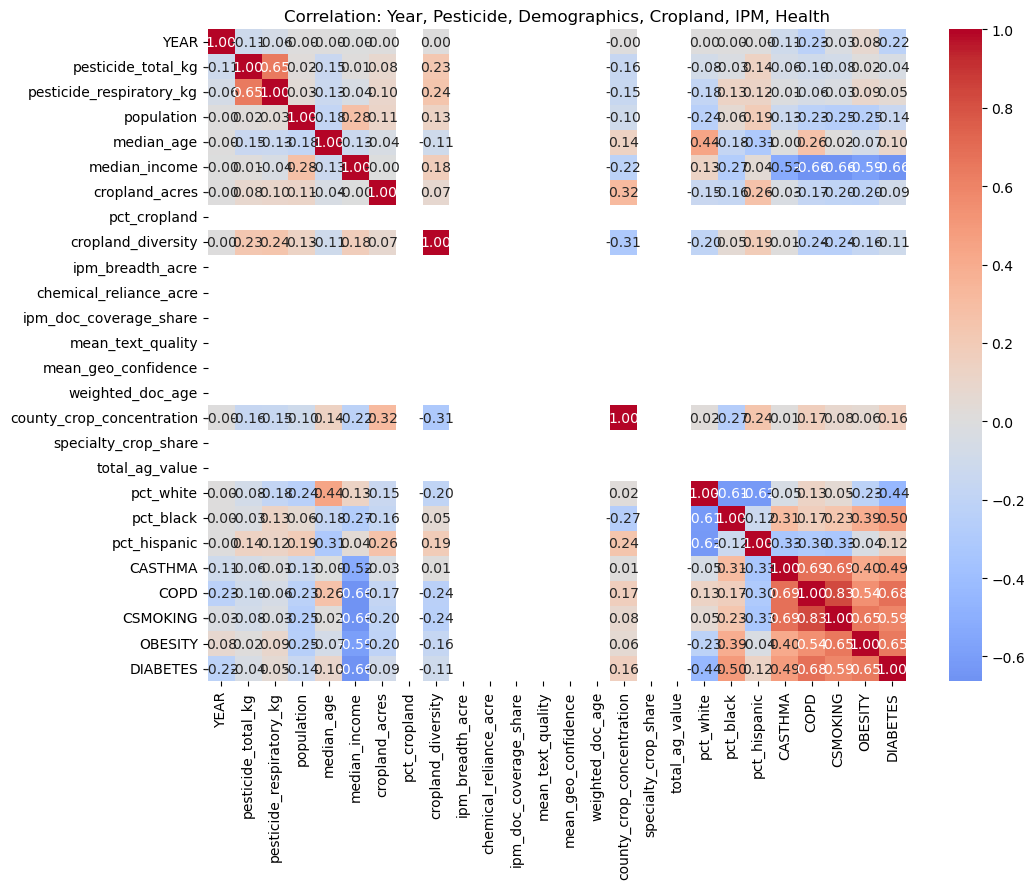

Correlation of IPM/crop indices with outcomes:
                           CASTHMA   COPD  pesticide_total_kg  \
ipm_breadth_acre             0.058 -0.033               0.047   
chemical_reliance_acre       0.094 -0.007               0.020   
ipm_doc_coverage_share       0.067 -0.029               0.041   
mean_text_quality              NaN    NaN                 NaN   
mean_geo_confidence         -0.211 -0.080               0.197   
weighted_doc_age            -0.460 -0.535               0.220   
ipm_breadth_value              NaN    NaN                 NaN   
chemical_reliance_value        NaN    NaN                 NaN   
county_crop_concentration    0.016  0.177              -0.169   
specialty_crop_share           NaN    NaN                 NaN   
total_ag_value                 NaN    NaN                 NaN   

                           pesticide_respiratory_kg  
ipm_breadth_acre                              0.171  
chemical_reliance_acre                        0.116  
ipm_doc_co

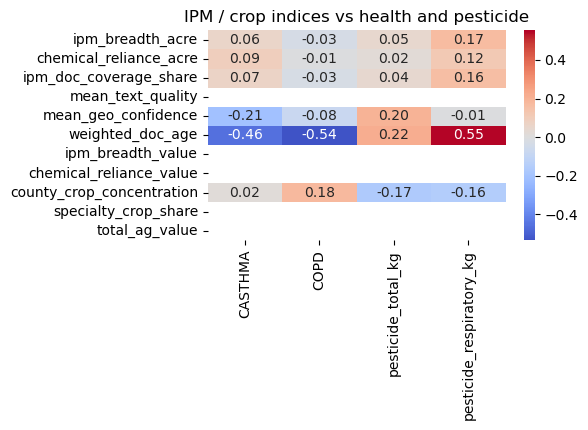

In [8]:
# Correlation matrix of key numeric variables (including temporal)
key_cols = [
    "YEAR",
    "pesticide_total_kg", "pesticide_respiratory_kg", "population", "median_age", "median_income",
    "cropland_acres", "pct_cropland", "cropland_diversity",
    "ipm_breadth_acre", "chemical_reliance_acre", "ipm_doc_coverage_share", "mean_text_quality", "mean_geo_confidence", "weighted_doc_age",
    "county_crop_concentration", "specialty_crop_share", "total_ag_value",
    "pct_white", "pct_black", "pct_hispanic",
    "CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"
]
key_cols = [c for c in key_cols if c in joint.columns]
corr_df = joint[key_cols].replace([-666666666, -222222222], np.nan)
corr_df = corr_df[(corr_df >= 0).all(axis=1) | corr_df.isna().any(axis=1)]
plt.figure(figsize=(11, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Year, Pesticide, Demographics, Cropland, IPM, Health")
plt.tight_layout()
plt.show()

# IPM and crop indices vs health outcomes
ipm_eda_cols = [c for c in ["ipm_breadth_acre", "chemical_reliance_acre", "ipm_doc_coverage_share", "mean_text_quality", "mean_geo_confidence", "weighted_doc_age", "ipm_breadth_value", "chemical_reliance_value", "county_crop_concentration", "specialty_crop_share", "total_ag_value"] if c in joint.columns]
outcome_cols = [c for c in ["CASTHMA", "COPD", "pesticide_total_kg", "pesticide_respiratory_kg"] if c in joint.columns]
if ipm_eda_cols and outcome_cols:
    ipm_out = joint[ipm_eda_cols + outcome_cols].copy().replace([-666666666, -222222222], np.nan)
    corr_ipm = ipm_out.corr().loc[ipm_eda_cols, outcome_cols]
    print("Correlation of IPM/crop indices with outcomes:")
    print(corr_ipm.round(3))
    fig, ax = plt.subplots(figsize=(6, max(4, len(ipm_eda_cols) * 0.4)))
    sns.heatmap(corr_ipm, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("IPM / crop indices vs health and pesticide")
    plt.tight_layout()
    plt.show()
else:
    print("IPM or outcome columns missing for IPM–outcome correlation.")

### 6c. Distribution maps across continental US

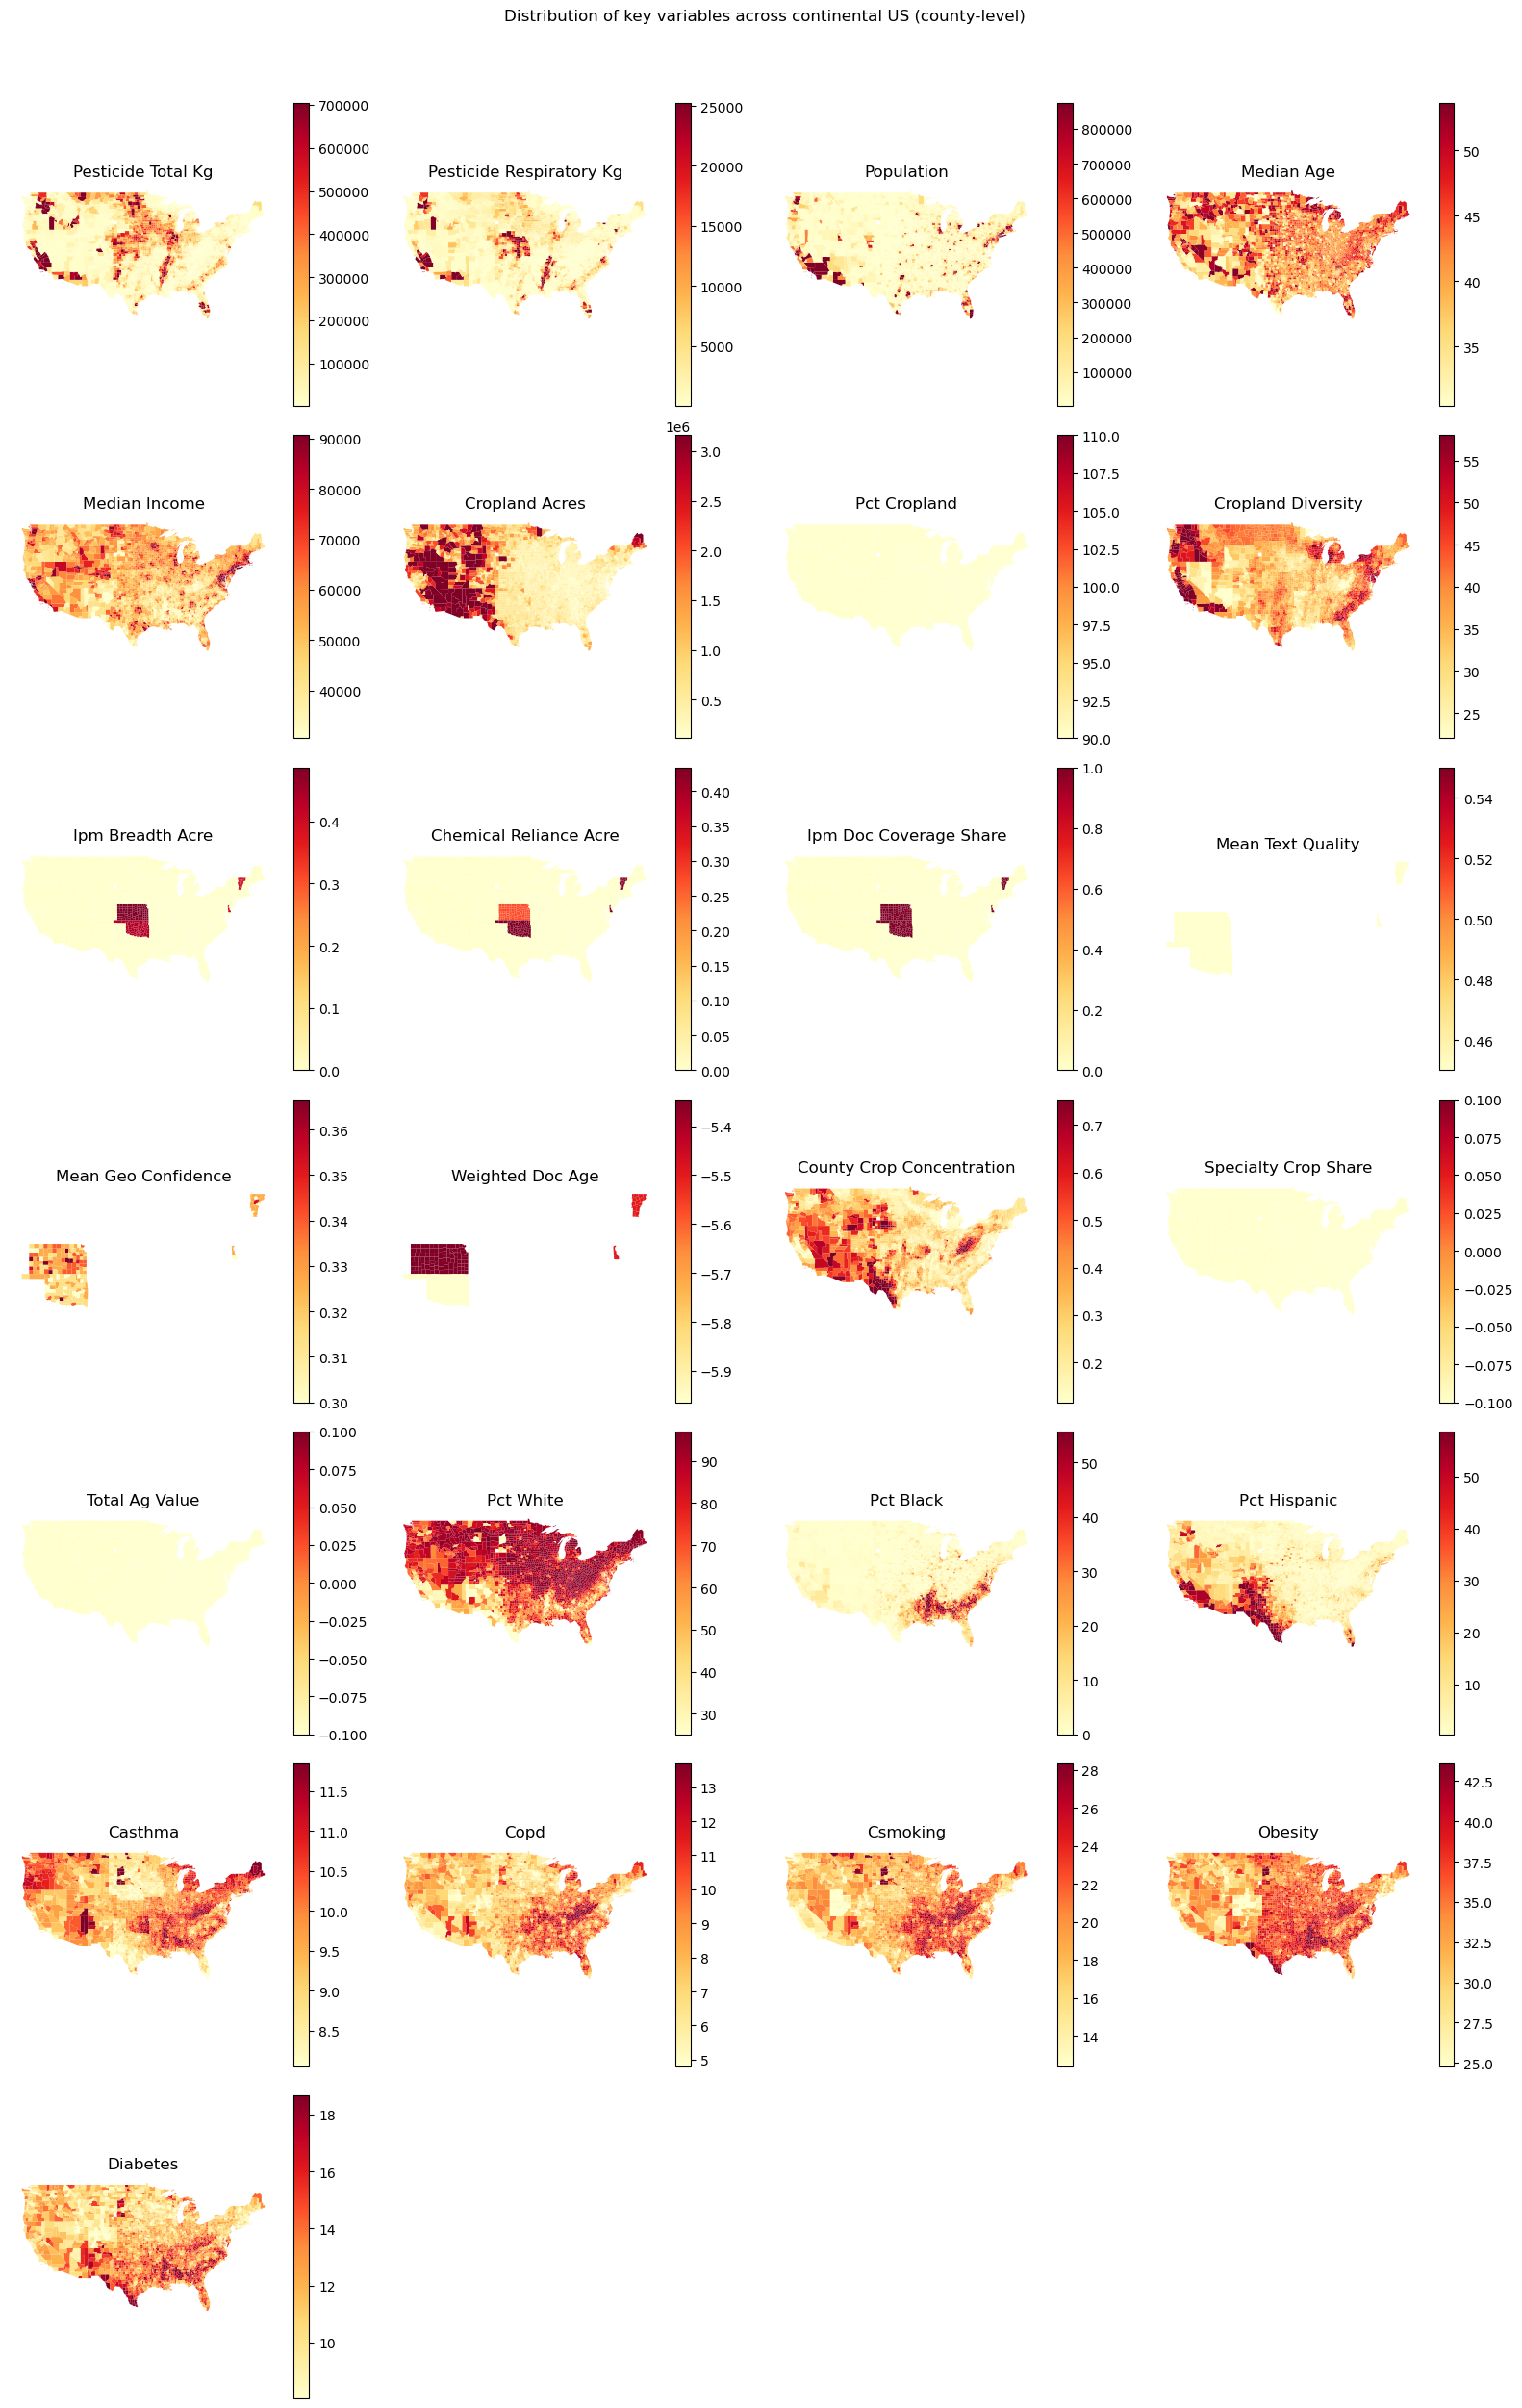

In [9]:
# Choropleth maps: distribution of each variable across continental US
if gpd is not None:
    COUNTIES_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
    counties_gdf = gpd.read_file(COUNTIES_URL)
    
    def to_fips5(x):
        if pd.isna(x): return ""
        try: return str(int(float(x))).zfill(5)
        except (ValueError, TypeError): return str(x).replace(".0", "").zfill(5)[:5]
    
    id_series = counties_gdf["id"] if "id" in counties_gdf.columns else counties_gdf.index.astype(str)
    counties_gdf["FIPS"] = id_series.apply(to_fips5)
    counties_gdf = counties_gdf[counties_gdf["FIPS"].str.len() == 5]
    
    # Continental US: exclude AK (02), HI (15), PR (72), territories (60,66,69,78)
    exclude_states = ["02", "15", "72", "60", "66", "69", "78"]
    counties_cont = counties_gdf[~counties_gdf["FIPS"].str[:2].isin(exclude_states)]
    
    map_vars = [
        "pesticide_total_kg", "pesticide_respiratory_kg", "population", "median_age", "median_income",
        "cropland_acres", "pct_cropland", "cropland_diversity",
        "ipm_breadth_acre", "chemical_reliance_acre", "ipm_doc_coverage_share", "mean_text_quality", "mean_geo_confidence", "weighted_doc_age",
        "county_crop_concentration", "specialty_crop_share", "total_ag_value",
        "pct_white", "pct_black", "pct_hispanic",
        "CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"
    ]
    map_vars = [c for c in map_vars if c in joint.columns]
    
    # One row per county for map (mean across years)
    map_df = joint.groupby("FIPS", as_index=True)[map_vars].mean().reset_index()
    map_df["FIPS"] = map_df["FIPS"].astype(str).str.zfill(5)
    merged = counties_cont.merge(map_df[["FIPS"] + map_vars], on="FIPS", how="inner")
    
    n_vars = len(map_vars)
    n_cols = 4
    n_rows = (n_vars + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for i, var in enumerate(map_vars):
        ax = axes[i]
        merged_plot = merged.dropna(subset=[var])
        vmin, vmax = merged_plot[var].quantile(0.02), merged_plot[var].quantile(0.98)
        merged_plot.plot(column=var, ax=ax, legend=True, cmap="YlOrRd", edgecolor="none", linewidth=0.1, vmin=vmin, vmax=vmax)
        ax.set_title(var.replace("_", " ").title())
        ax.axis("off")
    
    for j in range(len(map_vars), len(axes)):
        axes[j].axis("off")
    
    plt.suptitle("Distribution of key variables across continental US (county-level)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Install geopandas for choropleth maps: pip install geopandas")

### 6c2. Pesticide (kg) over time by conceptualization

Maps of **total kg** and **respiratory-relevant kg** (OP, Carbamate, Pyrethroid) by year (2016–2019). Each panel is one year; the same color scale is used across years so spatial and temporal patterns are comparable.

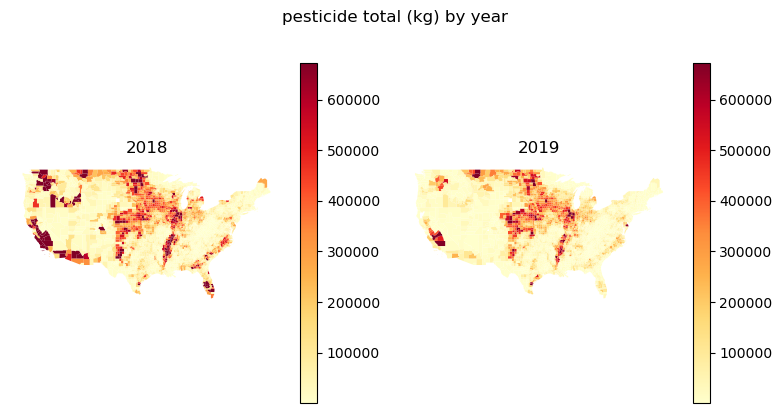

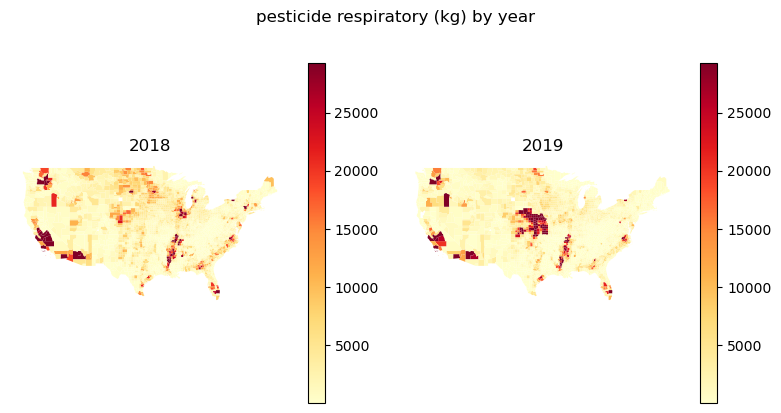

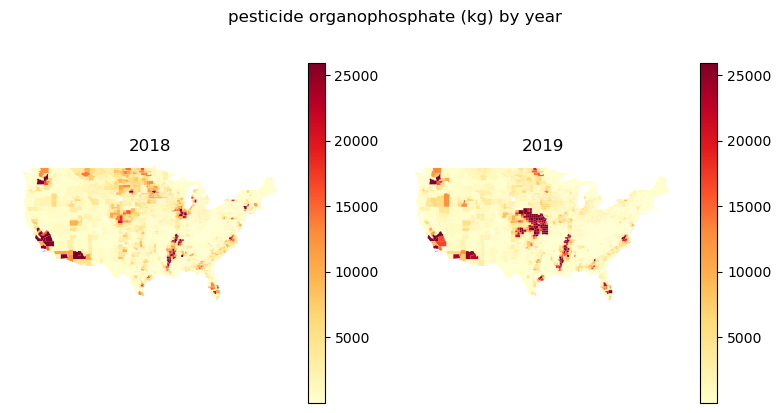

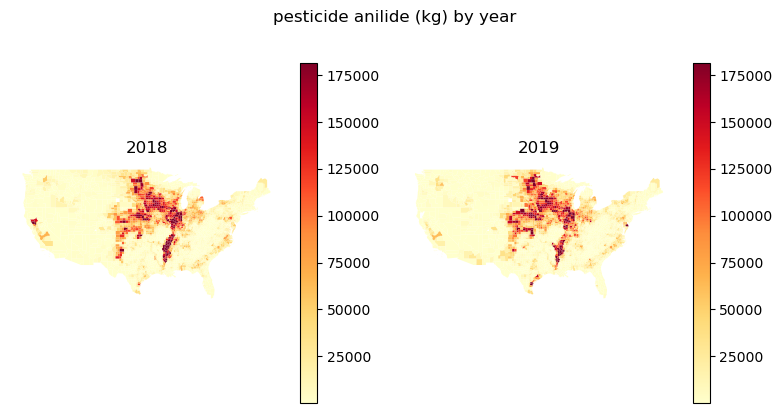

In [10]:
# Pesticide kg over time: one map per year for each conceptualization
if gpd is not None and "YEAR" in joint.columns:
    COUNTIES_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
    counties_gdf = gpd.read_file(COUNTIES_URL)
    def to_fips5(x):
        if pd.isna(x): return ""
        try: return str(int(float(x))).zfill(5)
        except (ValueError, TypeError): return str(x).replace(".0", "").zfill(5)[:5]
    id_series = counties_gdf["id"] if "id" in counties_gdf.columns else counties_gdf.index.astype(str)
    counties_gdf["FIPS"] = id_series.apply(to_fips5)
    counties_gdf = counties_gdf[counties_gdf["FIPS"].str.len() == 5]
    exclude_states = ["02", "15", "72", "60", "66", "69", "78"]
    counties_cont = counties_gdf[~counties_gdf["FIPS"].str[:2].isin(exclude_states)]

    # Total, respiratory-relevant, and selected chemical-class conceptualizations
    pest_vars = [
        "pesticide_total_kg",
        "pesticide_respiratory_kg",
        "pesticide_organophosphate_kg",
        "pesticide_anilide_kg",
    ]
    pest_vars = [c for c in pest_vars if c in joint.columns]
    years = sorted(joint["YEAR"].dropna().unique().astype(int).tolist())

    for pvar in pest_vars:
        fig, axes = plt.subplots(1, len(years), figsize=(4 * len(years), 4))
        if len(years) == 1:
            axes = [axes]
        vmin = joint[pvar].replace(0, np.nan).quantile(0.02)
        vmax = joint[pvar].quantile(0.98)
        for j, yr in enumerate(years):
            df_yr = joint[joint["YEAR"] == yr][["FIPS", pvar]].copy()
            df_yr["FIPS"] = df_yr["FIPS"].astype(str).str.zfill(5)
            merged = counties_cont.merge(df_yr, on="FIPS", how="inner")
            merged.plot(column=pvar, ax=axes[j], legend=True, cmap="YlOrRd", edgecolor="none",
                       vmin=vmin, vmax=vmax)
            axes[j].set_title(f"{yr}")
            axes[j].axis("off")
        plt.suptitle(f"{pvar.replace('_', ' ').replace('kg', '(kg)')} by year", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
else:
    if gpd is None:
        print("Install geopandas for maps: pip install geopandas")
    if "YEAR" not in joint.columns:
        print("No YEAR column; need county-year data for time maps.")

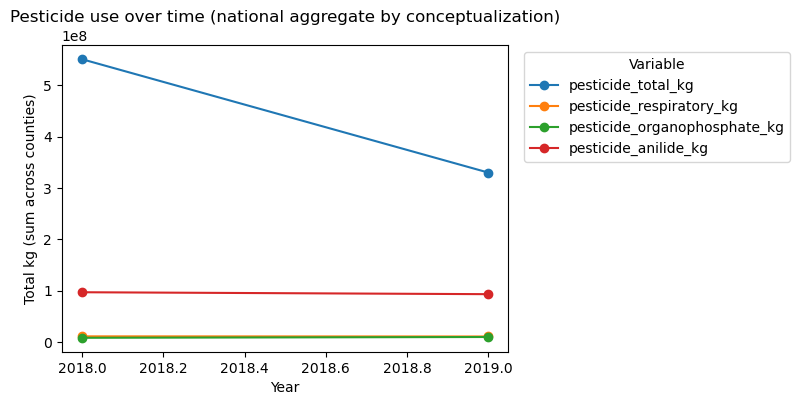

In [11]:
# Simple line graph: aggregate kg across all counties by year (collapsed over space)
if "YEAR" in joint.columns:
    pest_line_vars = [
        "pesticide_total_kg",
        "pesticide_respiratory_kg",
        "pesticide_organophosphate_kg",
        "pesticide_anilide_kg",
    ]
    pest_line_vars = [c for c in pest_line_vars if c in joint.columns]
    by_year = joint.groupby("YEAR")[pest_line_vars].sum()
    by_year.index = by_year.index.astype(int)
    by_year.plot(marker="o", figsize=(8, 4))
    plt.xlabel("Year")
    plt.ylabel("Total kg (sum across counties)")
    plt.title("Pesticide use over time (national aggregate by conceptualization)")
    plt.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No YEAR column; need county-year data for time trend.")

### 6d. Pesticide vs. respiratory outcomes

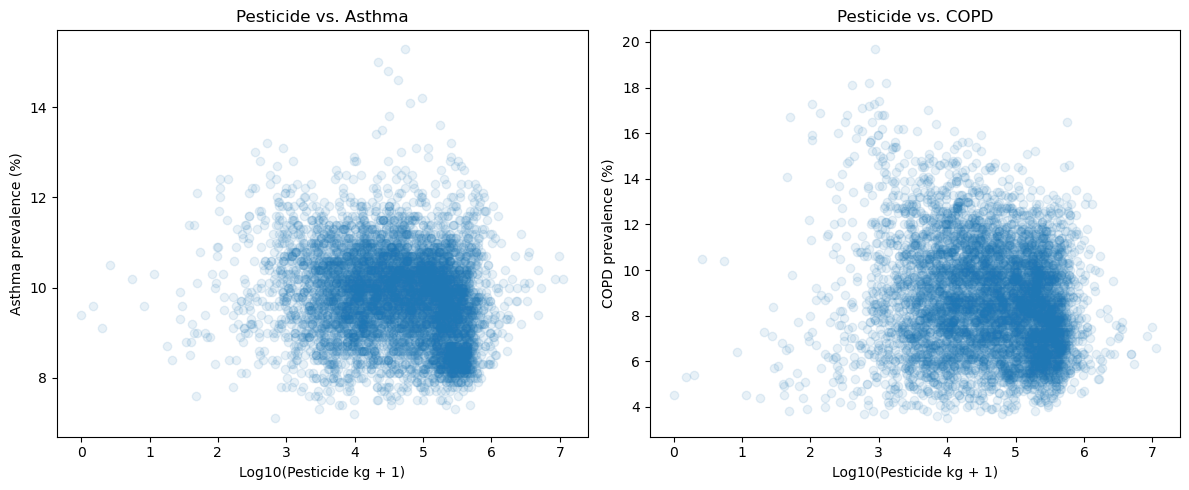

In [12]:
# Pesticide vs. respiratory outcomes (where PLACES available)
plot_df = joint.dropna(subset=["pesticide_respiratory_kg", "CASTHMA", "COPD"])
if len(plot_df) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(np.log10(plot_df["pesticide_total_kg"] + 1), plot_df["CASTHMA"], alpha=0.1)
    axes[0].set_xlabel("Log10(Pesticide kg + 1)")
    axes[0].set_ylabel("Asthma prevalence (%)")
    axes[0].set_title("Pesticide vs. Asthma")
    axes[1].scatter(np.log10(plot_df["pesticide_total_kg"] + 1), plot_df["COPD"], alpha=0.1)
    axes[1].set_xlabel("Log10(Pesticide kg + 1)")
    axes[1].set_ylabel("COPD prevalence (%)")
    axes[1].set_title("Pesticide vs. COPD")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient PLACES data for scatter. Run PLACES load (CDC URL or R) first.")

### 6e. Cropland vs. Pesticide

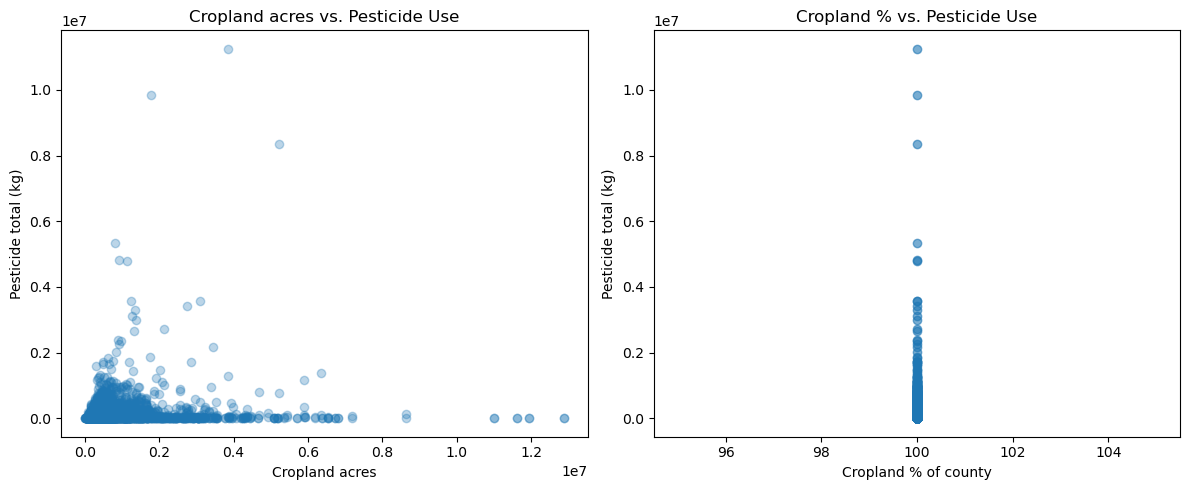

In [13]:
# Cropland vs. Pesticide (where cropland available)
plot_df = joint.dropna(subset=["cropland_acres", "pesticide_total_kg"])
if len(plot_df) > 5:
    n_plots = 2 if "pct_cropland" in plot_df.columns else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.atleast_1d(axes)
    axes[0].scatter(plot_df["cropland_acres"], plot_df["pesticide_total_kg"], alpha=0.3)
    axes[0].set_xlabel("Cropland acres")
    axes[0].set_ylabel("Pesticide total (kg)")
    axes[0].set_title("Cropland acres vs. Pesticide Use")
    if n_plots > 1:
        axes[1].scatter(plot_df["pct_cropland"], plot_df["pesticide_total_kg"], alpha=0.6)
        axes[1].set_xlabel("Cropland % of county")
        axes[1].set_ylabel("Pesticide total (kg)")
        axes[1].set_title("Cropland % vs. Pesticide Use")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient cropland data.")